# Homework 2

### Load data from mnist using the code below and reduce its size so the homework runs faster.  Only use the first 15000 images for training and 2000 for test.  The MNIST digits from keras datasets are already scaled to a value between 0 and 1 for the greyscale.  You do not need to do any further scaling.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images[:15000,:,:]
train_labels = train_labels[:15000]
test_images = test_images[:2000,:,:]
test_labels = test_labels[:2000]
train_images.shape

(15000, 28, 28)

In [26]:
train_images = train_images.reshape((15000, 28 * 28))
train_images = train_images.astype("float32") / 255 
test_images = test_images.reshape((2000, 28 * 28))
test_images = test_images.astype("float32") / 255

# Problem 1
### a) create a sequential model with two dense layers.  The first layer should have 512 neurons.  Use ReLU for the first layers activation.  Pick the best size and activation for the output layer

In [27]:
from tensorflow.keras import Sequential, layers

model = Sequential([
    layers.Input(shape=(28*28,)),          # flattened pixels
    layers.Dense(512, activation="relu"),  # first dense layer
    # output 10 classes with probabilities
    layers.Dense(10, activation="softmax") # second dense layer
])

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

# Problem 1
### b) Compile the model using the rmsprop optimizer.  Use the appropriate loss and metrics for the MNIST classification problem.
### c) Fit the model using 25 epochs, batch size 128 and use 33% of the data for validation (validation_split=0.33).  Save the history into a variable called history.

In [28]:
# b

model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",    # loss for integer labels
    metrics=["accuracy"]
)

In [29]:
# c

history = model.fit(
    train_images, 
    train_labels,
    epochs=25,                # training epochs
    batch_size=128,           # batch size
    validation_split=0.33,    # 33% of training
    verbose=1
)

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7198 - loss: 0.8952 - val_accuracy: 0.8629 - val_loss: 0.4501
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8988 - loss: 0.3568 - val_accuracy: 0.8822 - val_loss: 0.4134
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9189 - loss: 0.2914 - val_accuracy: 0.8824 - val_loss: 0.4271
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9304 - loss: 0.2593 - val_accuracy: 0.8826 - val_loss: 0.4123
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9250 - loss: 0.2588 - val_accuracy: 0.8948 - val_loss: 0.3835
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9267 - loss: 0.2490 - val_accuracy: 0.8893 - val_loss: 0.4202
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9345 - loss: 0.2408 - val_accuracy: 0.8919 - val_loss: 0.3941
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9308 - loss: 0.2368 - val_accuracy: 0.8782 - val_loss:

# Problem 1 
### d) predict the digit for the first ten test images, then compare to the actual values.

In [30]:
# Get model predictions for the test set
pred_probs = model.predict(test_images)          # shape(2000, 10)
pred_classes = np.argmax(pred_probs, axis=1)     # take highest-probability

# Show first 10 predictions vs actual
print("Predicted:", pred_classes[:10])
print("Actual:   ", test_labels[:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted: [7 2 1 0 4 1 4 9 6 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


# Problem 1
### e) Plot out the model accuracy vs epoch for the training and validation data.
### f) Plot the model loss vs epoch for the training and validation data.
### g) Print the model summary
### h) Did the model overfit?  Explain your reasoning.

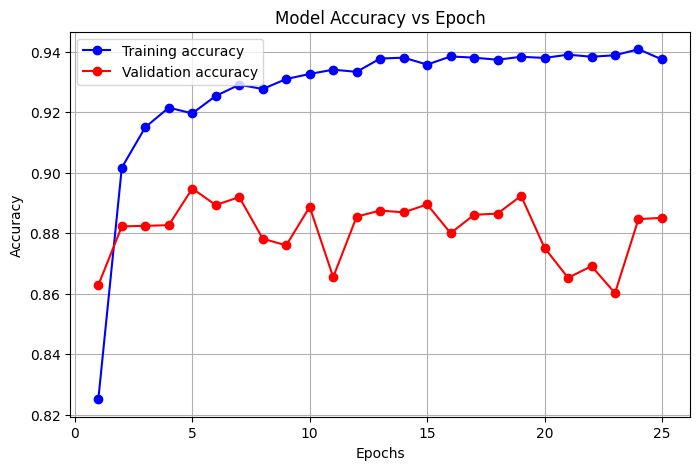

In [31]:
# e

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.title("Model Accuracy vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

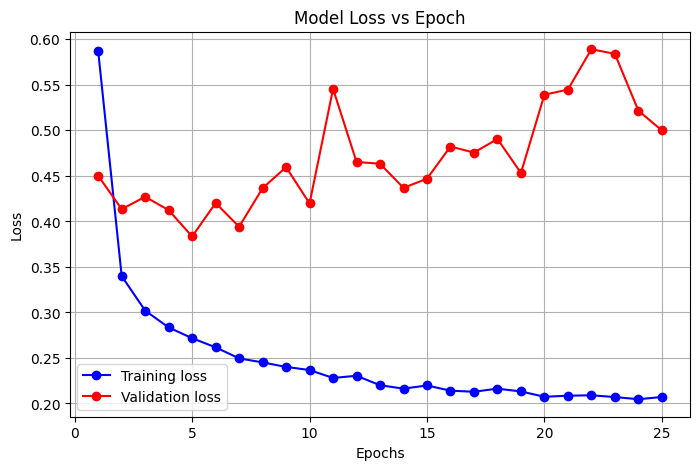

In [32]:
# f

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.title("Model Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# g

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,102 (3.11 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 407,052 (1.55 MB)

## 1-h: Yes. The model did overfit.
#### The training accuracy kept increasing toward ~95%, while the validation accuracy plateaued around ~85% and even fluctuated, showing that the model was not improving on unseen data. The divergence between training and validation curves (both in accuracy and loss) indicates overfitting.

# Problem 1
### Part i)  Do four-fold cross validation on the model above and print out the validation accuracy for each fold.  Also, plot the training and validation accuracy per fold.

In [34]:
from sklearn.model_selection import KFold

X = train_images
y = train_labels

# rebuild model with the same architecture
def build_model():
    m = Sequential([
        layers.Input(shape=(28*28,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    m.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

kf = KFold(n_splits=4, shuffle=True, random_state=42)

# store history dicts for plotting later
histories = []
# store final val accuracy per fold
val_acc_per_fold = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), start=1):
    print(f"Fold: {fold}")
    model_cv = build_model()
    hist = model_cv.fit(
        X[tr_idx], y[tr_idx],
        epochs=25, batch_size=128,
        validation_data=(X[va_idx], y[va_idx]),
        verbose=0
    )
    histories.append(hist.history)
    final_val_acc = hist.history["val_accuracy"][-1]
    val_acc_per_fold.append(final_val_acc)
    print(f"Accuracy: {final_val_acc:.4f}\n")


Fold: 1
Accuracy: 0.9045

Fold: 2
Accuracy: 0.8859

Fold: 3
Accuracy: 0.9011

Fold: 4
Accuracy: 0.9067



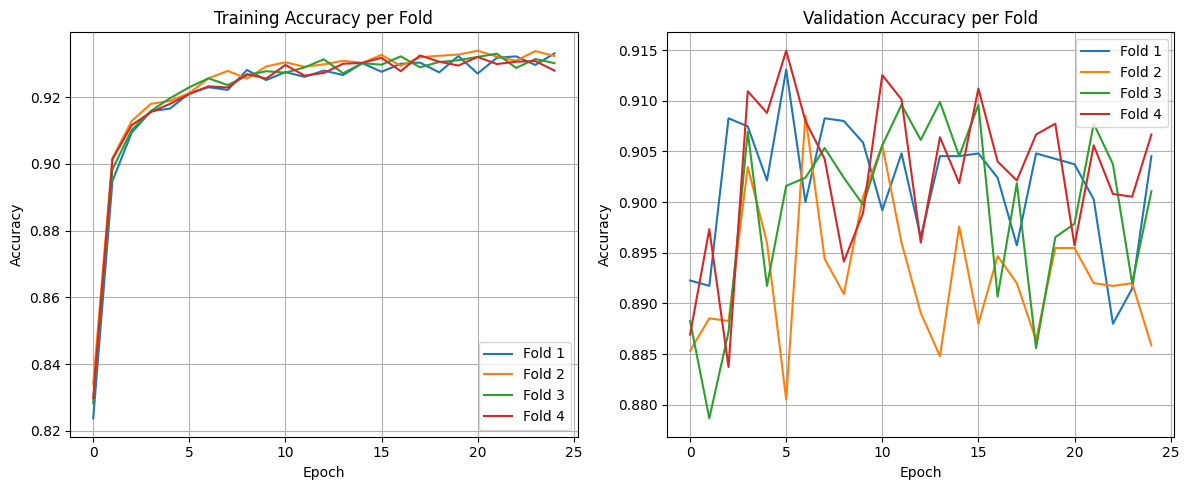

In [35]:
plt.figure(figsize=(12,5))

# Training accuracy per fold
plt.subplot(1,2,1)
for i, H in enumerate(histories, start=1):
    plt.plot(H["accuracy"], label=f"Fold {i}")
plt.title("Training Accuracy per Fold")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

# Validation accuracy per fold
plt.subplot(1,2,2)
for i, H in enumerate(histories, start=1):
    plt.plot(H["val_accuracy"], label=f"Fold {i}")
plt.title("Validation Accuracy per Fold")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

# Problem 2
### For problem 2, we are going to make a binary classifier using the same MNIST dataset.  We are going to classify digits as zero or not zero.
### a) Make the train_labels and test_labels data be zero or one with one being all digits that are not a zero (digits 1 - 9).

In [36]:
# Convert train_labels
train_labels_binary = np.where(train_labels == 0, 0, 1)

# Convert test_labels
test_labels_binary = np.where(test_labels == 0, 0, 1)

print("Original:", train_labels[:20])
print("Binary:  ", train_labels_binary[:20])

Original: [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]
Binary:   [1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


# Problem 2
### b) Create a model with one dense layer and one neuron.  Choose the appropriate activation for binary classification.

In [37]:
binary_model = Sequential([
    layers.Input(shape=(28*28,)),    # input layer
    layers.Dense(1, activation="sigmoid")  # for binary classification
])

binary_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

# Problem 2
### c) Compile the model using rmsprop for the optimizer.  Choose the best loss and metrics for binary classification

In [38]:
from tensorflow.keras.metrics import AUC

binary_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",          # corrected for sigmoid output
    metrics=["accuracy", AUC(name="auc")]
)

# Problem 2
### d) Fit the model and use the test_images and test_labels for the validation data instead of doing a validation split on the training data.  Use 50 epochs and the proper loss and metrics for a binary classification problem.

In [39]:
history_bin = binary_model.fit(
    train_images, train_labels_binary,
    epochs=50,
    batch_size=128,
    validation_data=(test_images, test_labels_binary),
    verbose=1
)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8496 - auc: 0.5784 - loss: 0.4019 - val_accuracy: 0.9670 - val_auc: 0.9645 - val_loss: 0.1263
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9735 - auc: 0.9700 - loss: 0.1097 - val_accuracy: 0.9815 - val_auc: 0.9893 - val_loss: 0.0696
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9842 - auc: 0.9907 - loss: 0.0600 - val_accuracy: 0.9855 - val_auc: 0.9951 - val_loss: 0.0518
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9873 - auc: 0.9937 - loss: 0.0484 - val_accuracy: 0.9880 - val_auc: 0.9965 - val_loss: 0.0434
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9892 - auc: 0.9956 - loss: 0.0388 - val_accuracy: 0.9885 - val_auc: 0.9974 - val_loss: 0.0393
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9893 - auc: 0.9940 - loss: 0.0379 - val_accuracy: 0.9890 - val_auc: 0.9977 - val_loss: 0.0363
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━

# Problem 2
### e) Plot out the model accuracy vs epoch for the traning and validation data.
### f) Plot the model loss vs epoch for the training and validation data.
### g) print the model summary
### h) Did the model overfit?  Explain your reasoning.

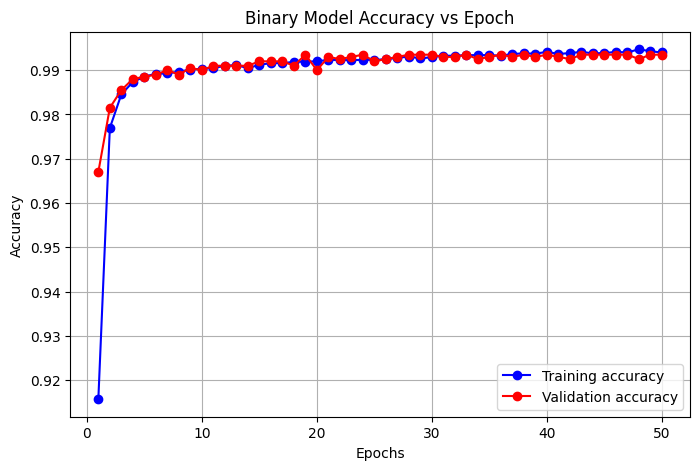

In [40]:
# e

train_acc = history_bin.history["accuracy"]
val_acc   = history_bin.history["val_accuracy"]
epochs    = range(1, len(train_acc) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.title("Binary Model Accuracy vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

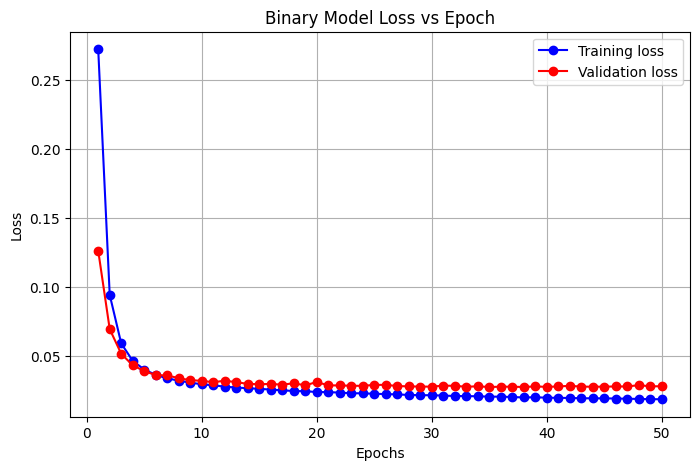

In [41]:
# f

train_loss = history_bin.history["loss"]
val_loss   = history_bin.history["val_loss"]
epochs     = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.title("Binary Model Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# g

binary_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,572 (6.14 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 787 (3.08 KB)

## 2-h: No. The model did not overfit.
#### Training and validation accuracy remained nearly identical ~99.3%, and the loss curves also stayed close. This indicates the model generalized well to unseen data rather than memorizing the training set.